In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import os

#-----------------------------------------------------------------

# Neural Networks
from sklearn.neural_network import MLPRegressor

# Stratified K-Fold
from sklearn.model_selection import StratifiedKFold, train_test_split

# Time
import time

#-----------------------------------------------------------------


#Model evaluation
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, median_absolute_error, mean_absolute_percentage_error
import statsmodels.api as sm

# Load Created Functions
from functions import *

# Set random seed for reproducibility
np.random.seed(40111) 

In [2]:
# Define relative path to the preprocessed data folder (outside "notebooks/")
data_path = "../data_feature_selected/"

# Load preprocessed datasets
X_train = pd.read_csv(f"{data_path}X_train_final.csv", index_col=0)
X_val   = pd.read_csv(f"{data_path}X_val_final.csv", index_col=0)
test    = pd.read_csv(f"{data_path}test_final.csv", index_col=0)

# Load target variables and squeeze to convert DataFrame to Series since they have only one column
y_train = pd.read_csv(f"{data_path}y_train.csv", index_col=0).squeeze()
y_val   = pd.read_csv(f"{data_path}y_val.csv", index_col=0).squeeze()

In [ ]:
# # Create a function to fit the model on both training and validation data and measure training time
# def model_fit(model, X_train, y_train):
#     start_time = time.time()
#     model.fit(X_train, y_train)
#     end_time = time.time()
#     training_time = end_time - start_time
#     print(f"Training time: {training_time:.2f} seconds")
#     return model

# Testar diferentes parâmetros com um seguimento lógico

Começar com apenas uma camada escondida.

O parâmetro do random_state = 42 é usado em todos os modelos aqui testados para garantir reproducibilidade e ser possível comparar os vários resultados obtidos.

In [ ]:
model_hls_1 = MLPRegressor(hidden_layer_sizes=(30), random_state=42).fit(X_train, y_train)
comparison_metrics(model_hls_1, X_train, y_train, X_val, y_val)

Training time: 22.89 seconds


/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,Metric,Train,Validation,Iteration
0,R2,8.491116e-01,8.443488e-01,200
1,Adjusted R2,8.489501e-01,8.436801e-01,200
2,MAE,2.199064e+03,2.219944e+03,200
3,MSE,1.421598e+07,1.512465e+07,200
4,RMSE,3.770409e+03,3.889042e+03,200
5,MedAE,1.415515e+03,1.401455e+03,200
6,MAPE (%),1.377437e-01,1.367205e-01,200


Agora vou experimentar aumentar o nº de iterações pq em cima vi que o modelo para nas 200 iterações que é o default máximo.

Acho que aqui pelos valores do R2 podemos dizer que os resultados não sofrem de overfit nem underfit pq os valores de R2 no train e no val são mais ou menos parecidos.

In [ ]:
model_maxiter_1 = MLPRegressor(hidden_layer_sizes=(30), max_iter=500, random_state=42).fit(X_train, y_train)
comparison_metrics(model_maxiter_1, X_train, y_train, X_val, y_val)

Training time: 54.71 seconds


/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,Metric,Train,Validation,Iteration
0,R2,8.679552e-01,8.638134e-01,500
1,Adjusted R2,8.678138e-01,8.632282e-01,500
2,MAE,2.001322e+03,2.028216e+03,500
3,MSE,1.244063e+07,1.323328e+07,500
4,RMSE,3.527128e+03,3.637757e+03,500
5,MedAE,1.228748e+03,1.227774e+03,500
6,MAPE (%),1.220565e-01,1.227547e-01,500


Depois disto, vimos que os valores melhoram um pouco. No entanto o modelo para na mesma no nº máximo de iterações definido. Ou seja, dando possibilidade de continuar a iterar para além dass 500 iterações é possivel que seham obtidos melhores valores.

Antes de aumentar o nº máximo de iterações vou testar trocar a função de ativação para ver se esta provoca já alguma alteração significativa nos resultados.

In [ ]:
model_act_1 = MLPRegressor(hidden_layer_sizes=(30), activation='tanh', max_iter=500, random_state=42).fit(X_train, y_train)
comparison_metrics(model_act_1, X_train, y_train, X_val, y_val)

Training time: 62.81 seconds


/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,Metric,Train,Validation,Iteration
0,R2,-1.569632e+00,-1.532153e+00,500
1,Adjusted R2,-1.572383e+00,-1.543032e+00,500
2,MAE,1.220563e+04,1.224532e+04,500
3,MSE,2.420985e+08,2.460497e+08,500
4,RMSE,1.555951e+04,1.568597e+04,500
5,MedAE,9.977015e+03,1.008701e+04,500
6,MAPE (%),6.485921e-01,6.476219e-01,500


In [ ]:
model_act_1 = MLPRegressor(hidden_layer_sizes=(30), activation='logistic', max_iter=500, random_state=42).fit(X_train, y_train)
comparison_metrics(model_act_1, X_train, y_train, X_val, y_val)

Training time: 59.78 seconds


/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,Metric,Train,Validation,Iteration
0,R2,-1.571493e+00,-1.533963e+00,500
1,Adjusted R2,-1.574246e+00,-1.544850e+00,500
2,MAE,1.221261e+04,1.225229e+04,500
3,MSE,2.422738e+08,2.462256e+08,500
4,RMSE,1.556515e+04,1.569158e+04,500
5,MedAE,9.984221e+03,1.009422e+04,500
6,MAPE (%),6.490818e-01,6.481100e-01,500


Os resultados obtidos são péssimos! O R2 passa a um valor negativo.

Assim percebemos que a função de ativação de default - RELU é a melhor! Voltamos então para o que tínhamos antes e aumentamos apenas o nº max de iterações um pouco mais

In [ ]:
model_maxiter_2 = MLPRegressor(hidden_layer_sizes=(30), activation='relu', max_iter=1000, random_state=42).fit(X_train, y_train)
comparison_metrics(model_maxiter_2, X_train, y_train, X_val, y_val)

/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,Metric,Train,Validation,Iteration
0,R2,8.765520e-01,8.720168e-01,1000
1,Adjusted R2,8.764198e-01,8.714670e-01,1000
2,MAE,1.936409e+03,1.966647e+03,1000
3,MSE,1.163068e+07,1.243614e+07,1000
4,RMSE,3.410379e+03,3.526491e+03,1000
5,MedAE,1.195372e+03,1.186324e+03,1000
6,MAPE (%),1.184506e-01,1.200640e-01,1000


Sem dúvida que os resultados voltaram a melhorar com o aumento de nº de iterações. Ainda assim e mais uma vez, as 1000 iterações foram executadas. O que significa que o modelo não converge e que poderá ainda continuar a aprender / melhorar.
No entanto, penso que o aumento de iterações vai tornar o algoritmo ainda mais demorado e que as melhoras não vão ser muito muito significativas.

Antes de testar aumentar novamente o nº de iterações vou testar alterar outros parâmetros que tb possam melhorar os resulatdos.

`Para além disto na aula vimos que traçar a curva da Loss pode ajudar-nos a perceber se precisamos ou não de mais iterações. Assim vou traçar a cruva da loss e tentar fazer esta análise com o último modelo testado`

<Axes: >

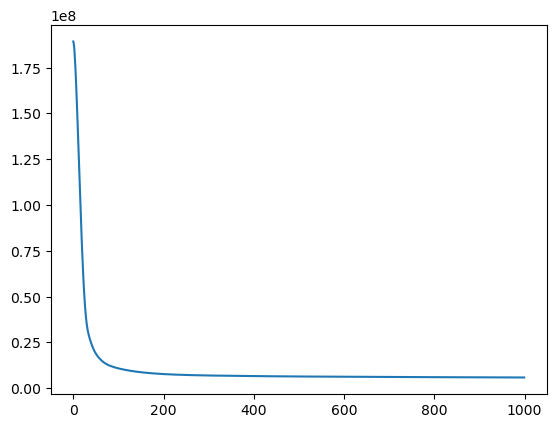

In [20]:
#import matplotlib.pyplot as plt
#import seaborn as sns

losses = model_maxiter_2.loss_curve_
iterations = range(model_maxiter_2.n_iter_)
sns.lineplot(x = iterations, y = losses)

O gráfico da loss mostra-nos que o modelo se está a portar como esperado, no sentido que o valor da loss diminui. "O formato típico de convergência aparece aqui: queda rápida → estabilização."

No entanto o valor final ainda se mantém alto, pelo que mais testes devem ser feitos, no sentido de testar mais parâmetros ou alterar algo no pré-processamento dos dados.


Assim o próximo passo que vou fazer é alterar o parâmetro do solver. Na default temos 'adam' e o algoritmo permite ainda usar 'lbfgs’ e ‘sgd’.
Vou testar 'sgd' e não vou testar o outro pq apenas funciona em datasets pequenos e o stor 100% que disse que não serve.

In [ ]:
# model_solver_1 = MLPRegressor(hidden_layer_sizes=(30), activation='relu', solver = 'sgd', max_iter=1000, random_state=42).fit(X_train, y_train)
# comparison_metrics(model_solver_1, X_train, y_train, X_val, y_val)

O código anterior deu erro pq criou um ciclo infinito. Pelo que percebi este parâmetro não deve ser alterado sozinho, mas em conjunto com outros parâmetros como learning_rate.

O solver = 'sgd' é muito sensível e precisa de alterações como mencionado antes.

Vou então agora testar alterar a learning_rate combinada com o solver 'sgd' para ver se obtemos melhores valores.

`!!! ATENÇÃO:` A learning_rate é um parâmetro que apenas se altera quando solver = 'sgd'. O professor tem isto escrito na 2ª aula de MLP e na documentação do sklearn tb está escrito isto.

Para este parâmetro da learning_rate existem 3 opções:
- **constant:** default (já testada)
- **invscaling:** vai diminuindo o learning rate ao longo de cada iteração
- **adaptive:** podemos pensar como um adam light. Usa a learing rate até que seja útil e quando nao for mais útil divi se por 5 e usamos essa learning rate mais pequena até que nao seja mais util e assim sucessivamente

**LEARNING_RATE = 'INVSCALING'**

Como já percebemos antes a learning rate vai diminuindo. Neste caso a learning rate inicial é calculada assim: learning_rate_init / (t^power_t).
Ou seja, este parâmetro vai estar a ser tb influenciado por outros parâmetros que podemos alterar dentro da função do sklearn.

In [ ]:
model_lr_1 = MLPRegressor(hidden_layer_sizes=(30), activation='relu', learning_rate = 'invscaling', max_iter=1000, random_state=42).fit(X_train, y_train)
comparison_metrics(model_lr_1, X_train, y_train, X_val, y_val)

/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,Metric,Train,Validation,Iteration
0,R2,8.756605e-01,8.713529e-01,1000
1,Adjusted R2,8.755274e-01,8.708001e-01,1000
2,MAE,1.947613e+03,1.981753e+03,1000
3,MSE,1.171467e+07,1.250066e+07,1000
4,RMSE,3.422670e+03,3.535627e+03,1000
5,MedAE,1.201677e+03,1.204706e+03,1000
6,MAPE (%),1.180696e-01,1.195130e-01,1000


Os resultados obtidos aqui são praticamente iguais aos anteriores a nível de R2 e MAE.
Antes de tentarmos alterar estes segundos parâmetros que influenciam a learning_rate = 'invscaling' vamos testar o learning_rate = 'adaptative'

In [ ]:
model_lr_2 = MLPRegressor(hidden_layer_sizes=(30), activation='relu', learning_rate = 'adaptive', max_iter=1000, random_state=42).fit(X_train, y_train)
comparison_metrics(model_lr_2, X_train, y_train, X_val, y_val)

/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,Metric,Train,Validation,Iteration
0,R2,8.794764e-01,8.746836e-01,1000
1,Adjusted R2,8.793474e-01,8.741452e-01,1000
2,MAE,1.910712e+03,1.948216e+03,1000
3,MSE,1.135515e+07,1.217701e+07,1000
4,RMSE,3.369741e+03,3.489558e+03,1000
5,MedAE,1.176746e+03,1.175279e+03,1000
6,MAPE (%),1.162093e-01,1.175798e-01,1000


Os resultados tb foram parecidos com os anteriores. Um pouco melhores mas nada demais e pode ter sido "sorte"

Agora vamos pegar no modelo `model_lr_1`e testar diferentes valores da learning_rate_init e do power_t.

In [26]:
# Comecei por tentar perceber quando devo aumentar ou diminuir a learning rate init. Perguntei ao chat

In [ ]:
model_lri_pt_1 = MLPRegressor(hidden_layer_sizes=(30), activation='relu', learning_rate = 'invscaling', learning_rate_init = 0.5, max_iter=1000, random_state=42).fit(X_train, y_train)
comparison_metrics(model_lri_pt_1, X_train, y_train, X_val, y_val)

# Hidden Layer Size

In [ ]:
# MLPRegressor(hidden_layer_sizes=(100,)) - demoram mais tempo a correr e não obtemos valores assim tão bons
# MLPRegressor(hidden_layer_sizes=(50, 50)) - demoram mais tempo a correr e não obtemos valores assim tão bons


# model_hls_1 = MLPRegressor(hidden_layer_sizes=(30,20))
# model_hls_2 = MLPRegressor(hidden_layer_sizes=(40, 30, 20, 10))
# model_hls_3 = MLPRegressor(hidden_layer_sizes=(40,30))



# MLPRegressor(hidden_layer_sizes=(40, 30, 20, 10, 5))
# MLPRegressor(hidden_layer_sizes=(40, 30, 20))
# MLPRegressor(hidden_layer_sizes=(50, 10, 10, 10))
# MLPRegressor(hidden_layer_sizes=(50, 30, 20, 10))
# MLPRegressor(hidden_layer_sizes=(10, 20, 30, 40))
# MLPRegressor(hidden_layer_sizes=(5, 10, 20, 30)) - PÉSSIMO
# MLPRegressor(hidden_layer_sizes=(20, 20))
# MLPRegressor(hidden_layer_sizes=(20, 20, 20))
# MLPRegressor(hidden_layer_sizes=(20, 20, 20, 20))
# MLPRegressor(hidden_layer_sizes=(30, 20, 10))
# MLPRegressor(hidden_layer_sizes=(10, 10, 10, 10)) - ficou pior que o (20,20,20)
# MLPRegressor(hidden_layer_sizes=(30,30)) - ficou pior que o (20,20)
# MLPRegressor(hidden_layer_sizes=(10, 10)) - ficou pior que o (20,20)
# MLPRegressor(hidden_layer_sizes=(10, 10, 10)) - ficou pior que o (20,20,20)

In [70]:
model_fit(model_hls_1, X_train, y_train, X_val, y_val)
comparison_metrics(model_hls_1, X_train, y_train, X_val, y_val)

Training time: 33.97 seconds


/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,Metric,Train,Validation,Iteration
0,R2,8.860799e-01,8.809257e-01,200
1,Adjusted R2,8.859580e-01,8.804141e-01,200
2,MAE,1.854041e+03,1.898783e+03,200
3,MSE,1.073300e+07,1.157047e+07,200
4,RMSE,3.276126e+03,3.401539e+03,200
5,MedAE,1.136911e+03,1.141249e+03,200
6,MAPE (%),1.134262e-01,1.152482e-01,200


In [ ]:
model_fit(model_hls_2, X_train, y_train, X_val, y_val)
comparison_metrics(model_hls_2, X_train, y_train, X_val, y_val)
#acho que o modelo overfitta um pouco

Training time: 74.02 seconds


/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,Metric,Train,Validation,Iteration
0,R2,9.213186e-01,9.121509e-01,200
1,Adjusted R2,9.212344e-01,9.117735e-01,200
2,MAE,1.599480e+03,1.711005e+03,200
3,MSE,7.412982e+06,8.536310e+06,200
4,RMSE,2.722679e+03,2.921696e+03,200
5,MedAE,1.010282e+03,1.042485e+03,200
6,MAPE (%),9.931865e-02,1.049856e-01,200


# Activation Function

Da aula o stor disse que a linear não vale a pena usar pq faz o mesmo que uma regressão linear simples.
A Relu é a default ou seja já foi testada antes.
Relativamente às outras o chat diz que:
- `tanh` é útil se os dados forem padronizados com média zero. Pode ser interessante se você quiser saídas centralizadas em torno de zero, mas treina um pouco mais devagar que relu.
- `logistic` Não recomendado para regressão contínua, porque satura rapidamente e dificulta o aprendizado.

Aqui vamos começar por usar o hidden_layer_size que "escolhemos" acima.

In [51]:
model_act_1 = MLPRegressor(hidden_layer_sizes=(40, 30, 20, 10), activation='tanh')
model_fit(model_act_1, X_train, y_train, X_val, y_val)
comparison_metrics(model_act_1, X_train, y_train, X_val, y_val)

Training time: 58.09 seconds


/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,Metric,Train,Validation,Iteration
0,R2,-2.785492e+00,-2.714439e+00,200
1,Adjusted R2,-2.789545e+00,-2.730397e+00,200
2,MAE,1.619988e+04,1.624081e+04,200
3,MSE,3.566509e+08,3.609325e+08,200
4,RMSE,1.888520e+04,1.899822e+04,200
5,MedAE,1.401616e+04,1.412616e+04,200
6,MAPE (%),9.466314e-01,9.468867e-01,200


In [58]:
model_act_2 = MLPRegressor(hidden_layer_sizes=(20, 10), activation='tanh')
model_fit(model_act_1, X_train, y_train, X_val, y_val)
comparison_metrics(model_act_1, X_train, y_train, X_val, y_val)

Training time: 60.19 seconds


/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,Metric,Train,Validation,Iteration
0,R2,-2.786589e+00,-2.715505e+00,200
1,Adjusted R2,-2.790643e+00,-2.731468e+00,200
2,MAE,1.620307e+04,1.624400e+04,200
3,MSE,3.567543e+08,3.610361e+08,200
4,RMSE,1.888794e+04,1.900095e+04,200
5,MedAE,1.401935e+04,1.412935e+04,200
6,MAPE (%),9.468833e-01,9.471368e-01,200


PÉSSIMOS RESULTADOS. Valores de R2 negativos o que mostra o quão maus são os nossos resultados

# Max_Iter

Percebemos antes que todos os modelos testados convergem. Ou seja, se puderem fazer mais iterações talvez obtenham melhores resultados. Aqui vamos então testar diferentes nº de iterações.

Começamos por usar o melhor hidden layer e a activation function RELU que é a default.

In [83]:
model_maxiter_1 = MLPRegressor(hidden_layer_sizes=(40, 30, 20, 10), activation='relu', max_iter=300)
model_fit(model_maxiter_1, X_train, y_train, X_val, y_val)
comparison_metrics(model_maxiter_1, X_train, y_train, X_val, y_val)
# o resultado obtido do MAE foi pior do que com apenas 200 iterações e pelos valores de R2 parece que o modelos overfitta

Training time: 79.98 seconds


/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


,Metric,Train,Validation,Iteration
0,R2,9.291214e-01,9.162746e-01,300
1,Adjusted R2,9.290455e-01,9.159148e-01,300
2,MAE,1.552918e+03,1.675262e+03,300
3,MSE,6.677840e+06,8.135614e+06,300
4,RMSE,2.584152e+03,2.852300e+03,300
5,MedAE,1.001938e+03,1.043596e+03,300
6,MAPE (%),9.744003e-02,1.042298e-01,300


In [81]:
model_maxiter_2 = MLPRegressor(hidden_layer_sizes=(30, 20), activation='relu', max_iter=300)
model_fit(model_maxiter_2, X_train, y_train, X_val, y_val)
comparison_metrics(model_maxiter_2, X_train, y_train, X_val, y_val)[2:]

Training time: 50.67 seconds


/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


,Metric,Train,Validation,Iteration
2,MAE,1.846986e+03,1.899604e+03,300
3,MSE,1.077087e+07,1.177519e+07,300
4,RMSE,3.281901e+03,3.431500e+03,300
5,MedAE,1.112233e+03,1.127432e+03,300
6,MAPE (%),1.136445e-01,1.155156e-01,300


<Axes: >

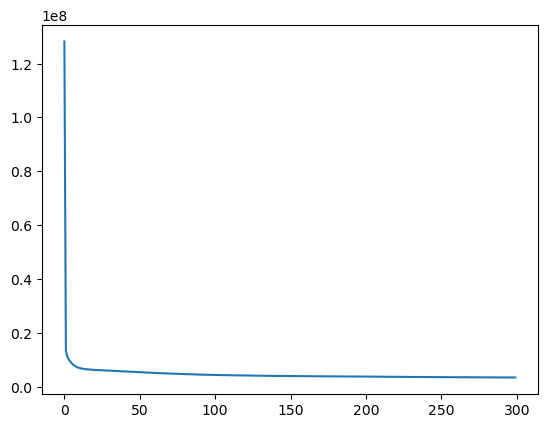

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

losses = model_maxiter_1.loss_curve_
iterations = range(model_maxiter_1.n_iter_)
sns.lineplot(x = iterations, y = losses)

# Melhores Resultados

DATA PREPROCESSING (original):

- `Outliers IQR multiplier:` 2.2
- `Scaling:`Standard

FEATURE SELECTION (original):

- `Remove Constant Features`: 0.001
- `Correlation between Features`: 0.95
- `Correlation With the target (Spearman)`: 0.2
- `Lasso:`0.1
- `Comparison between models`: n_agreed=2


In [ ]:
param_grid_mlp = {
    # Optimal architecture grid for 600k rows / 20 features
    "hidden_layer_sizes": [
        # Tier 1 — Medium models (fast, stable)
        (64,), (128,), (128, 64), (100, 50),
        # Tier 2 — Best performers in your tests
        (150, 100), (150, 100, 50), (200, 100),

        # Tier 3 — Larger models for marginal gains
        (200, 150, 100), (256, 128), (256, 128, 64),
    ],
    "activation": ["relu"],   # Activation. Best for tabular data
    "solver": ["adam"],       # Optimizer Adam is far superior for MLP in sklearn
    "alpha": [0.0005, 0.001, 0.002, 0.005],  # Regularization (L2 penalty), centered around your winning value (0.001)
    "learning_rate_init": [0.0003, 0.0005, 0.0007, 0.001], # Learning rate grid (finely tuned)
    "learning_rate": ["adaptive"],  # LR schedule. Works best with relu + large datasets
    "batch_size": [64, 128, 256], # Batch sizes (scaling-friendly)
    "early_stopping": [True], # Generalization
}

COM 15 ITERATIONS:

=== BEST MODEL (based on MAE) ===

Best train R2: 0.9236783927115079

Best validation R2: 0.9134128029118985

R2 Gap: 1.1113813942831496 %

Best train MAE: 1612.9224524596323

Best validation MAE: 1694.654104034056

MAE Gap: 5.0673019927143255 %

Best parameters: {'solver': 'adam', 'learning_rate_init': 0.001, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (256, 128), 'early_stopping': True, 'batch_size': 64, 'alpha': 0.002, 'activation': 'relu'}


COM 40 ITERATIONS (180min):

=== BEST MODEL (based on MAE) ===

Best train R2: 0.9281671965456616

Best validation R2: 0.9172916908077245

R2 Gap: 1.1717183906533404 %

Best train MAE: 1560.7015588608845

Best validation MAE: 1654.5482996018354

MAE Gap: 6.013112513929137 %

Best parameters: {'solver': 'adam', 'learning_rate_init': 0.0007, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (256, 128), 'early_stopping': True, 'batch_size': 64, 'alpha': 0.002, 'activation': 'relu'}

## MELHOR

DATA PREPROCESSING:

- `Outliers IQR multiplier:` 2.2
- `Scaling`: Standard

FEATURE SELECTION:

- `Remove Constant Features (variance)`: 0.1
- `Correlation between Features`: 0.8
- `Correlation With the target (Spearman)`: 0.2
- `Lasso:`0.1
- `Comparison between models`: n_agreed=2

In [ ]:
modelMLP = MLPRegressor(max_iter=300, 
                        warm_start=True, 
                        random_state=40111, 
                        tol=0.001)

param_grid_mlp = {
    "hidden_layer_sizes": [
        (200, 150),
        (250, 200, 150),
        (200, 150, 100)
    ],
    "activation": ["relu"],                      # Activation. Best for tabular data
    "solver": ["adam"],                           # Optimizer Adam is far superior for MLP in sklearn
    "alpha": [0.0005, 0.001, 0.002, 0.005],      # Regularization (L2 penalty), centered around your winning value (0.001)
    "learning_rate_init": [0.0007, 0.001, 0.0015, 0.002], # Learning rate grid (finely tuned)
    "learning_rate": ["adaptive"],               # LR schedule. Works best with relu + large datasets
    "batch_size": [64, 75, 95, 115],                          # Batch sizes (scaling-friendly)
    "early_stopping": [True],                    # Generalization
}

=== BEST MODEL (based on MAE) ===

Best train R2: 0.9341754723418472


Best validation R2: 0.9201013536552557

R2 Gap: 1.5065819113522247 %

Best train MAE: 1526.4111832016226

Best validation MAE: 1626.345371828429

MAE Gap: 6.5470031749371795 %

Best parameters: {'solver': 'adam', 'learning_rate_init': 0.0015, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (250, 200, 150), 'early_stopping': True, 'batch_size': 115, 'alpha': 0.001, 'activation': 'relu'}

In [ ]:
param_grid_mlp = {
    "hidden_layer_sizes": [
        # Tier 2 — Best performers in your tests
        (200, 100),

        # Tier 3 — Larger models for marginal gains
        (200, 150, 100), (256, 128), (256, 128, 64),
    ],
    "activation": ["relu"],   # Activation. Best for tabular data
    "solver": ["adam"],       # Optimizer Adam is far superior for MLP in sklearn
    "alpha": [0.0005, 0.001, 0.002, 0.005],  # Regularization (L2 penalty), centered around your winning value (0.001)
    "learning_rate_init": [0.0003, 0.0005, 0.0007, 0.001], # Learning rate grid (finely tuned)
    "learning_rate": ["adaptive"],  # LR schedule. Works best with relu + large datasets
    "batch_size": [64, 128], # Batch sizes (scaling-friendly)
    "early_stopping": [True], # Generalization
}

=== BEST MODEL (based on MAE) ===

Best train R2: 0.9392577592453302

Best validation R2: 0.9215601264686135

R2 Gap: 1.8842147006521675 %

Best train MAE: 1497.7211185492774

Best validation MAE: 1627.1221369250757

MAE Gap: 8.639860703916536 %

Best parameters: {'solver': 'adam', 'learning_rate_init': 0.001, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (200, 150, 100), 'early_stopping': True, 'batch_size': 64, 'alpha': 0.001, 'activation': 'relu'}

In [ ]:
modelMLP = MLPRegressor(max_iter=300, 
                        warm_start=True, 
                        random_state=40111, 
                        tol=0.001)

param_grid_mlp = {
    "hidden_layer_sizes": [
        (200, 150),
        (250, 200, 150),
        (200, 150, 100)
    ],
    "activation": ["relu"],                      # Activation. Best for tabular data
    "solver": ["adam"],                           # Optimizer Adam is far superior for MLP in sklearn
    "alpha": [0.0005, 0.001, 0.002, 0.005],      # Regularization (L2 penalty), centered around your winning value (0.001)
    "learning_rate_init": [0.0007, 0.001, 0.0015, 0.002], # Learning rate grid (finely tuned)
    "learning_rate": ["adaptive"],               # LR schedule. Works best with relu + large datasets
    "batch_size": [64, 75, 95, 115],                          # Batch sizes (scaling-friendly)
    "early_stopping": [True],                    # Generalization
}

=== BEST MODEL (based on MAE) ===

Best train R2: 0.931646690293966

Best validation R2: 0.9196338783160576

R2 Gap: 1.2894171259405138 %

Best train MAE: 1570.6938767811125

Best validation MAE: 1658.7605323112218

MAE Gap: 5.6068631088438385 %

Best parameters: {'solver': 'adam', 'learning_rate_init': 0.0015, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (250, 200, 150), 'early_stopping': True, 'batch_size': 75, 'alpha': 0.001, 'activation': 'relu'}

# Outros

DATA PREPROCESSING:

- `Outliers IQR multiplier:` 2.5
- `Scaling`: Standard

FEATURE SELECTION:

- `Remove Constant Features (variance)`: 0.1
- `Correlation between Features`: 0.8
- `Correlation With the target (Spearman)`: 0.3
- `Lasso:`0.1
- `Comparison between models`: n_agreed=2

In [ ]:
param_grid_mlp = {
    "hidden_layer_sizes": [
        (300, 150),
        (300, 200, 100),
        (200, 150, 100), (256, 128),
    ],
    "activation": ["relu", "tanh"],              # Activation. Best for tabular data
    "solver": ["adam"],                         # Optimizer Adam is far superior for MLP in sklearn
    "alpha": [0.0005, 0.001, 0.002, 0.005],  # Regularization (L2 penalty), centered around your winning value (0.001)
    "learning_rate_init": [0.0003, 0.0005, 0.0007, 0.001], # Learning rate grid (finely tuned)
    "learning_rate": ["adaptive"],           # LR schedule. Works best with relu + large datasets
    "batch_size": [32, 64, 128],             # Batch sizes (scaling-friendly)
    "early_stopping": [True],                # Generalization
    "n_iter_no_change": [20]
}

=== BEST MODEL (based on MAE) ===

Best train R2: 0.9292546647298109

Best validation R2: 0.9188729336279138

R2 Gap: 1.1172105447450928 %

Best train MAE: 1560.3703123208938

Best validation MAE: 1659.9484298831426

MAE Gap: 6.381697778787927 %

Best parameters: {'solver': 'adam', 'learning_rate_init': 0.0007, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (300, 200, 100), 'early_stopping': True, 'batch_size': 64, 'alpha': 0.001, 'activation': 'relu'}

DATA PREPROCESSING:

- `Outliers IQR multiplier:` 2.2
- `Scaling`: Robust

FEATURE SELECTION:

- `Remove Constant Features (variance)`: 0.1
- `Correlation between Features`: 0.85
- `Correlation With the target (Spearman)`: 0.2
- `Lasso:`0.1
- `Comparison between models`: n_agreed=2

In [ ]:
modelMLP = MLPRegressor(max_iter=300, 
                        warm_start=True, 
                        random_state=40111, 
                        tol=0.001)

param_grid_mlp = {
    "hidden_layer_sizes": [
        (300, 150),
        (200, 150, 100), (256, 128),
    ],
    "activation": ["relu"],                          # Activation. Best for tabular data
    "solver": ["adam"],                              # Optimizer Adam is far superior for MLP in sklearn
    "alpha": [0.001],                 # Regularization (L2 penalty), centered around your winning value (0.001)
    "learning_rate_init": [0.0005, 0.0007, 0.001],   # Learning rate grid (finely tuned)
    "learning_rate": ["adaptive"],                   # LR schedule. Works best with relu + large datasets
    "batch_size": [32, 64],                          # Batch sizes (scaling-friendly)
    "early_stopping": [True],                        # Generalization
}

=== BEST MODEL (based on MAE) ===

Best train R2: 0.9198432980403002

Best validation R2: 0.9110410146448089

R2 Gap: 0.9569329269718315 %

Best train MAE: 1650.275960488182

Best validation MAE: 1709.4217015256263

MAE Gap: 3.5839909477896046 %

Best parameters: {'solver': 'adam', 'learning_rate_init': 0.0005, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (200, 150, 100), 'early_stopping': True, 'batch_size': 32, 'alpha': 0.001, 'activation': 'relu'}